# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rimlazrek1/flyrank-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

## Setup (Local)

In [29]:
import json
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
while not (ROOT / "data" / "raw").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
except ImportError:
    pass

HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    import getpass
    HF_TOKEN = getpass.getpass("HF READ token (hf_...): ")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_PREV = (
    "read_parquet(["
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet', "
    f"'{REL}/fact_content_daily_performance/month=2026-04/*.parquet'"
    "])"
)
FACT_NEXT = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-05/*.parquet')"
FACT_MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
FACT_APR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')"

print("Connected.")
print("  FACT_PREV = month=2026-03 + 2026-04 (features)")
print("  FACT_NEXT = month=2026-05 (label)")


Connected.
  FACT_PREV = month=2026-03 + 2026-04 (features)
  FACT_NEXT = month=2026-05 (label)


## 1. Ranked actions + reason codes

**Question:** What should we do first, and why — in words a human trusts?

**Answer:** Rank eligible pages (`imp_prev >= 500`) by the w05 model score `P(is_ctr_underperformer)` on Mar–Apr → May. Use out-of-sample GroupKFold scores (score desc, then `imp_prev`) — not the w04 `ctr_gap` hand rule. Past `ctr_gap` is baseline-only, never a model feature.

Same `reason_code` → `action` map as w04/w05:

| reason_code | When | Action |
|---|---|---|
| `zero_click_visible` | past CTR = 0, visible tier | `check_tracking_first` |
| `high_visibility_ctr_gap` | past CTR below tier median, visible | `refresh_and_review_ctr` |
| `deep_tier_ctr_gap` | past CTR below tier median, deep | `ranking_not_ctr` |
| `general_ctr_monitor` | at/above past tier median | `monitor` |

In [30]:
LABEL = "is_ctr_underperformer"
FEATURE_COLS = ["imp_prev", "ctr_prev", "pos_avg_prev", "engagement_rate_prev", "position_tier"]
NUM_COLS = ["imp_prev", "ctr_prev", "pos_avg_prev", "engagement_rate_prev"]
TIER_ORDER = ["top_3", "page_1", "striking", "page_3_5", "deep"]
VISIBLE_TIERS = ("top_3", "page_1", "striking")
DEEP_TIERS = ("page_3_5", "deep")
IMP_FLOOR = 500
RANDOM_STATE = 42
N_FOLDS = 4
KS = (10, 20, 50)

ACTION_BY_REASON = {
    "zero_click_visible": "check_tracking_first",
    "high_visibility_ctr_gap": "refresh_and_review_ctr",
    "deep_tier_ctr_gap": "ranking_not_ctr",
    "general_ctr_monitor": "monitor",
}
ARCHETYPE_ORDER = list(ACTION_BY_REASON.keys())


def precision_at_k(scores, labels, k, tie_break=None):
    """Rank by score desc, then tie_break desc (same contract for rule and model)."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels)
    if tie_break is None:
        order = np.argsort(-scores, kind="mergesort")
    else:
        tb = np.asarray(tie_break, dtype=float)
        order = np.lexsort((-tb, -scores))
    k = min(k, len(order))
    return float(labels[order[:k]].mean())


def make_pipeline():
    prep = ColumnTransformer(
        [
            ("num", StandardScaler(), NUM_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["position_tier"]),
        ]
    )
    return Pipeline(
        [("prep", prep), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]
    )


def reason_code_of(row) -> str:
    tier = row["position_tier"]
    below = row["ctr_prev"] < row["tier_median_ctr"]
    if row["ctr_prev"] == 0 and tier in VISIBLE_TIERS:
        return "zero_click_visible"
    if below and tier in VISIBLE_TIERS:
        return "high_visibility_ctr_gap"
    if below and tier in DEEP_TIERS:
        return "deep_tier_ctr_gap"
    return "general_ctr_monitor"


# Same Mar–Apr → May frame as ML-07/08/09 (eligible past ∩ May outcome).
features = con.sql(
    f"""
    WITH prev_daily AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(gsc_impressions) AS imp_prev,
            SUM(gsc_clicks) AS clk_prev,
            AVG(NULLIF(gsc_avg_position, 0)) AS pos_avg_prev,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_prev,
            SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) AS engaged_prev
        FROM {FACT_PREV}
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= {IMP_FLOOR}
    ),
    prev_scored AS (
        SELECT *,
            CASE WHEN imp_prev > 0 THEN 100.0 * clk_prev / imp_prev END AS ctr_prev,
            CASE WHEN sessions_prev > 0 THEN 100.0 * engaged_prev / sessions_prev END AS engagement_rate_prev,
            CASE
                WHEN pos_avg_prev <= 3 THEN 'top_3'
                WHEN pos_avg_prev <= 10 THEN 'page_1'
                WHEN pos_avg_prev <= 20 THEN 'striking'
                WHEN pos_avg_prev <= 50 THEN 'page_3_5'
                ELSE 'deep'
            END AS position_tier
        FROM prev_daily
        WHERE pos_avg_prev > 0
    ),
    prev_ranked AS (
        SELECT *,
            MEDIAN(ctr_prev) OVER (PARTITION BY position_tier) AS tier_median_ctr
        FROM prev_scored
    ),
    next_daily AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(gsc_impressions) AS imp_next,
            SUM(gsc_clicks) AS clk_next,
            AVG(NULLIF(gsc_avg_position, 0)) AS pos_avg_next
        FROM {FACT_NEXT}
        GROUP BY 1, 2
        HAVING SUM(gsc_impressions) >= {IMP_FLOOR}
    ),
    next_scored AS (
        SELECT *,
            CASE WHEN imp_next > 0 THEN 100.0 * clk_next / imp_next END AS ctr_next,
            CASE
                WHEN pos_avg_next <= 3 THEN 'top_3'
                WHEN pos_avg_next <= 10 THEN 'page_1'
                WHEN pos_avg_next <= 20 THEN 'striking'
                WHEN pos_avg_next <= 50 THEN 'page_3_5'
                ELSE 'deep'
            END AS position_tier_next
        FROM next_daily
        WHERE pos_avg_next > 0
    ),
    next_labeled AS (
        SELECT *,
            CASE
                WHEN ctr_next < MEDIAN(ctr_next) OVER (PARTITION BY position_tier_next)
                     AND imp_next >= {IMP_FLOOR}
                THEN 1 ELSE 0
            END AS is_ctr_underperformer
        FROM next_scored
    )
    SELECT
        p.*,
        n.imp_next,
        n.ctr_next,
        n.is_ctr_underperformer
    FROM prev_ranked p
    INNER JOIN next_labeled n
        USING (client_hash_id, content_hash_id)
"""
).df()

model_df = features.dropna(subset=["ctr_prev", "pos_avg_prev"]).copy()
model_df["engagement_rate_prev"] = model_df["engagement_rate_prev"].fillna(0)
model_df["baseline_score"] = model_df["tier_median_ctr"] - model_df["ctr_prev"]  # never a feature
model_df = model_df.sort_values(["client_hash_id", "content_hash_id"]).reset_index(drop=True)

# Client GroupKFold — OOS scores for the queue (same contract as Week 5/6)
gkf = GroupKFold(n_splits=N_FOLDS)
groups = model_df["client_hash_id"].to_numpy()
fold_rows = []
oos_parts = []

for fold, (tr_idx, te_idx) in enumerate(
    gkf.split(model_df[FEATURE_COLS], model_df[LABEL], groups), start=1
):
    train_df = model_df.iloc[tr_idx]
    test_df = model_df.iloc[te_idx].copy()
    pipe = make_pipeline().fit(train_df[FEATURE_COLS], train_df[LABEL])
    test_df["model_score"] = pipe.predict_proba(test_df[FEATURE_COLS])[:, 1]
    test_df["fold"] = fold
    oos_parts.append(test_df)

    y_elig = test_df[LABEL].to_numpy()
    imp_elig = test_df["imp_prev"].to_numpy()
    base_rate = float(y_elig.mean())
    for method, scores in [
        ("baseline (ctr_gap)", test_df["baseline_score"].to_numpy()),
        ("logistic regression", test_df["model_score"].to_numpy()),
    ]:
        row = {
            "fold": fold,
            "method": method,
            "n_test_pages": int(len(test_df)),
            "n_test_clients": int(test_df["client_hash_id"].nunique()),
            "base_rate": base_rate,
        }
        for k in KS:
            row[f"precision_at_{k}"] = precision_at_k(scores, y_elig, k, tie_break=imp_elig)
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows)
summary = (
    fold_df.groupby("method", as_index=False)
    .agg(
        n_folds=("fold", "count"),
        n_test_pages_mean=("n_test_pages", "mean"),
        base_rate_mean=("base_rate", "mean"),
        precision_at_10=("precision_at_10", "mean"),
        precision_at_20=("precision_at_20", "mean"),
        precision_at_50=("precision_at_50", "mean"),
    )
    .set_index("method")
)

holdout = {
    "split": f"GroupKFold clients n_splits={N_FOLDS}",
    "n_test_pages_mean": float(summary.loc["logistic regression", "n_test_pages_mean"]),
    "n_test_clients_mean": float(fold_df.loc[fold_df["method"] == "logistic regression", "n_test_clients"].mean()),
    "base_rate": float(summary.loc["logistic regression", "base_rate_mean"]),
    "precision_at_10": float(summary.loc["logistic regression", "precision_at_10"]),
    "precision_at_20": float(summary.loc["logistic regression", "precision_at_20"]),
    "precision_at_50": float(summary.loc["logistic regression", "precision_at_50"]),
}

queue = pd.concat(oos_parts, ignore_index=True)
assert len(queue) == len(model_df), "OOS queue should cover every eligible page once"

queue["reason_code"] = queue.apply(reason_code_of, axis=1)
queue["archetype"] = queue["reason_code"]  # same bucket → action map
queue["action"] = queue["reason_code"].map(ACTION_BY_REASON)

# Dual ranks (model + baseline) — single playbook CSV for the paper
queue = queue.sort_values(["model_score", "imp_prev"], ascending=[False, False])
queue["model_rank"] = np.arange(1, len(queue) + 1)
queue = queue.sort_values(["baseline_score", "imp_prev"], ascending=[False, False])
queue["baseline_rank"] = np.arange(1, len(queue) + 1)
queue = queue.sort_values("model_rank").reset_index(drop=True)  # playbook order = model

mix = (
    queue.groupby("archetype")
    .agg(pages=("content_hash_id", "count"), action=("action", "first"))
    .reindex(ARCHETYPE_ORDER)
)
mix["pct_of_all_pages"] = 100.0 * mix["pages"] / len(queue)

print(f"Pages: {len(queue):,} | clients: {queue['client_hash_id'].nunique()}")
print(
    f"GroupKFold mean Precision@50: {holdout['precision_at_50']:.3f} "
    f"(base rate {holdout['base_rate']:.3f}, ~{holdout['n_test_clients_mean']:.1f} clients/fold)\n"
)
print("Archetype → action:")
print(mix.to_string(float_format=lambda x: f"{x:.1f}"))
print("\nTop 10 (model order):")
print(
    queue.nsmallest(10, "model_rank")[
        [
            "model_rank",
            "baseline_rank",
            "content_hash_id",
            "imp_prev",
            "ctr_prev",
            "position_tier",
            "archetype",
            "action",
            "reason_code",
        ]
    ].to_string(
        index=False,
        formatters={"imp_prev": "{:,.0f}".format, "ctr_prev": "{:.4f}".format},
    )
)


Pages: 52,001 | clients: 41
GroupKFold mean Precision@50: 0.945 (base rate 0.513, ~10.2 clients/fold)

Archetype → action:
                         pages                  action  pct_of_all_pages
archetype                                                               
zero_click_visible        1695    check_tracking_first               3.3
high_visibility_ctr_gap  15757  refresh_and_review_ctr              30.3
deep_tier_ctr_gap         4435         ranking_not_ctr               8.5
general_ctr_monitor      30114                 monitor              57.9

Top 10 (model order):
 model_rank  baseline_rank          content_hash_id  imp_prev ctr_prev position_tier               archetype                 action             reason_code
          1          48036 content_eadb33b5df496f4a 1,416,482   0.9250         top_3     general_ctr_monitor                monitor     general_ctr_monitor
          2          10926 content_77276ad7a26f4905   343,846   0.1411        page_1 high_visibility_ctr

## 2. Intended use and limits

**Question:** Who uses this, for what — and where does it stop being valid?

**Answer:**

- **Who / what:** one editor or SEO reviewer, once a month, picking which pages to open first. A ranked review list — not automation, not a quality score, not a causal claim.
- **Limits:** the May label is a proxy (CTR below tier median), not “page is broken”; tier medians are portfolio-specific; metrics use client GroupKFold on `imp_prev >= 500`; zero-click SERPs can look like weak titles; thin-volume pages stay out of the queue.
- **Wrong call cost:** wasted review time or a missed page — not dangerous.
- **Honest claim:** decision-support only. No claim that editing raises clicks. Past `ctr_gap` is an honest baseline on this frame (May label), not perfect by design; the model’s job is better Precision@K and stake ordering.

The cell below prints the Precision@K table and a simple top-50 review-cost sketch (15 min/page assumption).

In [31]:
# GroupKFold mean Precision@K — same rows / tie-break as Week 5
base_rate_elig = float(summary.loc["logistic regression", "base_rate_mean"])
bench = pd.DataFrame(
    [
        {
            "ranking": "base rate",
            "P@10": base_rate_elig,
            "P@20": base_rate_elig,
            "P@50": base_rate_elig,
        },
        {
            "ranking": "ML-07 rule (past ctr_gap)",
            "P@10": float(summary.loc["baseline (ctr_gap)", "precision_at_10"]),
            "P@20": float(summary.loc["baseline (ctr_gap)", "precision_at_20"]),
            "P@50": float(summary.loc["baseline (ctr_gap)", "precision_at_50"]),
        },
        {
            "ranking": "ML-08 model",
            "P@10": float(summary.loc["logistic regression", "precision_at_10"]),
            "P@20": float(summary.loc["logistic regression", "precision_at_20"]),
            "P@50": float(summary.loc["logistic regression", "precision_at_50"]),
        },
    ]
).set_index("ranking")

print(
    f"Client GroupKFold mean — eligible pages (imp_prev >= {IMP_FLOOR}, "
    f"~{holdout['n_test_pages_mean']:,.0f} test pages/fold):"
)
print(bench.round(3).to_string())

MINUTES = 15  # assumption — not measured
K = 50
hits = bench.loc["ML-08 model", "P@50"] * K
print(
    f"\nCost/value (assumed {MINUTES} min/page, top {K}): "
    f"{K * MINUTES / 60:.1f}h → ~{hits:.0f} real May underperformers, "
    f"~{K - hits:.0f} false alarms. "
    f"Base rate on eligible would find ~{base_rate_elig * K:.0f}."
)


Client GroupKFold mean — eligible pages (imp_prev >= 500, ~13,000 test pages/fold):
                            P@10   P@20   P@50
ranking                                       
base rate                  0.513  0.513  0.513
ML-07 rule (past ctr_gap)  0.850  0.738  0.775
ML-08 model                1.000  1.000  0.945

Cost/value (assumed 15 min/page, top 50): 12.5h → ~47 real May underperformers, ~3 false alarms. Base rate on eligible would find ~26.


## 3. Human review + the no-go list

**Question:** What must a person check before acting? What should never be automated?

**Answer — before acting, check:**
1. Past impressions ≥ 500? If not → out of queue / monitor only.
2. Is past CTR compared to its **own past tier** median? Site-wide “low CTR” is meaningless.
3. Is the SERP zero-click (brand / snippet / AI answer)? If yes → don’t rewrite yet.
4. Is tracking intact? If not → send to analyst, not editor.

**Never automate:**
- auto-publish title/meta rewrites
- prune / merge / redirect without a human
- act on thin-volume pages (`imp_prev < 500`)
- treat deep-tier as a CTR fix
- promise a click lift to a client
- use past `ctr_gap` / May columns / `trend_*` as model features
- send the raw queue to a client as an audit

A human stays in the loop because the model ranks “looks like the flagged group”, not “needs work”. The cell below shows example false alarms.

In [32]:
# False alarms: high OOS model score, but May label = 0
false_alarms = queue[queue[LABEL] == 0].nlargest(5, "model_score")[
    ["content_hash_id", "imp_prev", "ctr_prev", "position_tier", "model_score"]
]
print("Top-5 false alarms (high OOS score, not May underperformers):")
print(false_alarms.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

monitor_share = float(queue["action"].eq("monitor").mean())
print(f"\nShare of queue that is monitor-only: {monitor_share:.1%}")

# Same wording as the markdown no-go list — kept for playbook_metrics.json
NO_GO = [
    "auto-publish title/meta rewrites",
    "prune / merge / redirect without a human",
    "act on thin_volume pages (imp_prev < 500)",
    "treat deep_tier as a CTR fix",
    "promise a click lift to a client",
    "use past ctr_gap / May columns / trend_* as model features",
    "send the raw queue to a client as an audit",
]

FORBIDDEN = {
    "ctr_gap",
    "baseline_score",
    "tier_median_ctr",
    "ctr_next",
    "imp_next",
    "trend_direction",
    "trend_pct",
}
assert not (FORBIDDEN & set(FEATURE_COLS)), "forbidden feature in model"


Top-5 false alarms (high OOS score, not May underperformers):
         content_hash_id   imp_prev  ctr_prev position_tier  model_score
content_a8998878909cee77 28941.0000    0.0138        page_1       0.9112
content_83167156f76e33e5 16340.0000    0.0184        page_1       0.9015
content_2ba481a694613001  1451.0000    0.0000        page_1       0.8997
content_87b9188513d77529 26046.0000    0.0269        page_1       0.8992
content_6ac93124c81a6993 20288.0000    0.0148        page_1       0.8991

Share of queue that is monitor-only: 57.9%


## 4. Monitoring / retrain triggers

**Question:** What would tell you the recommendations went stale?

**Answer:** Rebuild ranks with March-only past features vs April-only past features (same May label). Low top-K overlap means the queue goes stale when the past window shifts.

Use those numbers for **cadence only** — a page can leave because it improved, the tier median moved, or month noise. We can’t separate those.

**Triggers (manual, not production):** rebuild monthly. Retrain sooner if top-50 overlap collapses, base rate drifts, clients are added/removed, or GA4 coverage drops.

The cell below measures Mar-only vs Apr-only overlap.

In [33]:
def month_feature_frame(fact_sql: str) -> pd.DataFrame:
    """One calendar month as past features, joined to the same May labels."""
    month_df = con.sql(
        f"""
        WITH prev_daily AS (
            SELECT
                client_hash_id, content_hash_id,
                SUM(gsc_impressions) AS imp_prev,
                SUM(gsc_clicks) AS clk_prev,
                AVG(NULLIF(gsc_avg_position, 0)) AS pos_avg_prev,
                SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_prev,
                SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions ELSE 0 END) AS engaged_prev
            FROM {fact_sql}
            GROUP BY 1, 2
            HAVING SUM(gsc_impressions) >= {IMP_FLOOR}
        ),
        prev_scored AS (
            SELECT *,
                CASE WHEN imp_prev > 0 THEN 100.0 * clk_prev / imp_prev END AS ctr_prev,
                CASE WHEN sessions_prev > 0 THEN 100.0 * engaged_prev / sessions_prev END AS engagement_rate_prev,
                CASE
                    WHEN pos_avg_prev <= 3 THEN 'top_3'
                    WHEN pos_avg_prev <= 10 THEN 'page_1'
                    WHEN pos_avg_prev <= 20 THEN 'striking'
                    WHEN pos_avg_prev <= 50 THEN 'page_3_5'
                    ELSE 'deep'
                END AS position_tier
            FROM prev_daily
            WHERE pos_avg_prev > 0
        )
        SELECT *,
            MEDIAN(ctr_prev) OVER (PARTITION BY position_tier) AS tier_median_ctr
        FROM prev_scored
        """
    ).df()
    month_df = month_df.dropna(subset=["ctr_prev", "pos_avg_prev"]).copy()
    month_df["engagement_rate_prev"] = month_df["engagement_rate_prev"].fillna(0)
    labels = model_df[["content_hash_id", "client_hash_id", LABEL]]
    out = month_df.merge(labels, on=["content_hash_id", "client_hash_id"], how="inner")
    return out


def scored_month_queue(month_df: pd.DataFrame, name: str) -> pd.DataFrame:
    """OOS-style scores via the same client GroupKFold recipe on one-month features."""
    parts = []
    gkf_m = GroupKFold(n_splits=N_FOLDS)
    for tr_idx, te_idx in gkf_m.split(
        month_df[FEATURE_COLS], month_df[LABEL], month_df["client_hash_id"]
    ):
        train_df = month_df.iloc[tr_idx]
        test_df = month_df.iloc[te_idx].copy()
        pipe = make_pipeline().fit(train_df[FEATURE_COLS], train_df[LABEL])
        test_df["model_score"] = pipe.predict_proba(test_df[FEATURE_COLS])[:, 1]
        parts.append(test_df)
    h = pd.concat(parts, ignore_index=True)
    h = h.sort_values(["model_score", "imp_prev"], ascending=[False, False]).reset_index(drop=True)
    h["queue_rank"] = np.arange(1, len(h) + 1)
    print(f"{name}: {len(h):,} pages")
    return h


mar_only = scored_month_queue(month_feature_frame(FACT_MAR), "Mar-only features → May label")
apr_only = scored_month_queue(month_feature_frame(FACT_APR), "Apr-only features → May label")

decay = {}
for k in (50, 500):
    a = set(mar_only.nsmallest(k, "queue_rank")["content_hash_id"])
    b = set(apr_only.nsmallest(k, "queue_rank")["content_hash_id"])
    decay[f"top_{k}_overlap"] = len(a & b) / k

common = mar_only.merge(apr_only, on="content_hash_id", suffixes=("_1", "_2"))
decay["rank_corr"] = float(common["queue_rank_1"].rank().corr(common["queue_rank_2"].rank()))

print(f"\nTop-50 overlap:  {decay['top_50_overlap']:.2f}")
print(f"Top-500 overlap: {decay['top_500_overlap']:.2f}")
print(f"Rank correlation: {decay['rank_corr']:.2f}")


Mar-only features → May label: 43,598 pages
Apr-only features → May label: 49,878 pages

Top-50 overlap:  0.42
Top-500 overlap: 0.23
Rank correlation: 0.68


## 5. Exports for the paper

**Question:** Where do the ranked queue and paper figures get saved?

**Answer:** Export the ranked queue and any reuse figures to `work/outputs/` — those exact files are what the paper builds on next week.

Saved → c:\Users\rimla\Desktop\work_folder\flyrank-internship\work\outputs\action_playbook_queue.csv


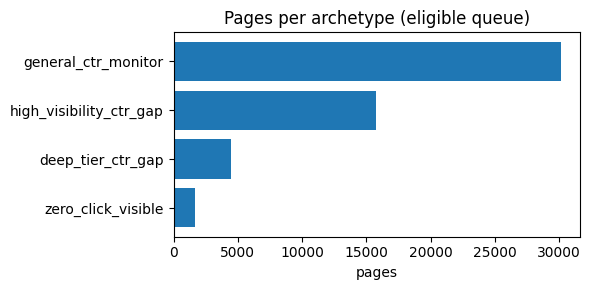

Saved → c:\Users\rimla\Desktop\work_folder\flyrank-internship\work\outputs\w07_archetype_mix.png


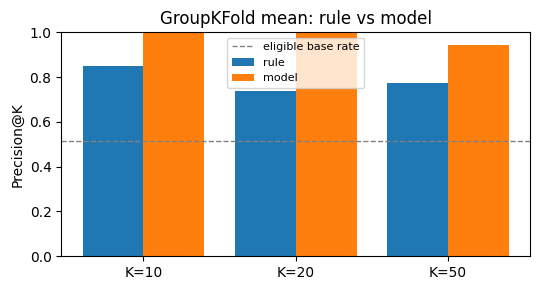

Saved → c:\Users\rimla\Desktop\work_folder\flyrank-internship\work\outputs\w07_precision_at_k.png


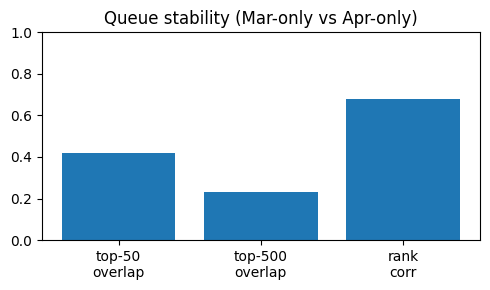

Saved → c:\Users\rimla\Desktop\work_folder\flyrank-internship\work\outputs\w07_queue_stability.png
Saved → c:\Users\rimla\Desktop\work_folder\flyrank-internship\work\outputs\playbook_metrics.json


In [34]:
OUT = ROOT / "work" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

# Ranked queue (gitignored — regenerated by this notebook)
export_cols = [
    "model_rank", "baseline_rank", "fold", "content_hash_id", "client_hash_id",
    "imp_prev", "ctr_prev", "pos_avg_prev", "position_tier",
    "imp_next", "ctr_next",
    "baseline_score", "model_score",
    "archetype", "action", "reason_code", LABEL,
]
queue_path = OUT / "action_playbook_queue.csv"
queue[export_cols].to_csv(queue_path, index=False)
print(f"Saved → {queue_path}")

# Figures for the paper (same folder as the queue)
fig, ax = plt.subplots(figsize=(6, 3))
plot = mix.dropna(subset=["pages"]).sort_values("pages")
ax.barh(plot.index.astype(str), plot["pages"])
ax.set_xlabel("pages")
ax.set_title("Pages per archetype (eligible queue)")
fig.tight_layout()
fig_path = OUT / "w07_archetype_mix.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

fig, ax = plt.subplots(figsize=(5.5, 3))
ks = [10, 20, 50]
x = np.arange(len(ks))
ax.bar(x - 0.2, [bench.loc["ML-07 rule (past ctr_gap)", f"P@{k}"] for k in ks], 0.4, label="rule")
ax.bar(x + 0.2, [bench.loc["ML-08 model", f"P@{k}"] for k in ks], 0.4, label="model")
ax.axhline(base_rate_elig, ls="--", color="grey", lw=1, label="eligible base rate")
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in ks])
ax.set_ylabel("Precision@K")
ax.set_ylim(0, 1)
ax.set_title("GroupKFold mean: rule vs model")
ax.legend(fontsize=8)
fig.tight_layout()
fig_path = OUT / "w07_precision_at_k.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

fig, ax = plt.subplots(figsize=(5, 3))
vals = [decay["top_50_overlap"], decay["top_500_overlap"], decay["rank_corr"]]
ax.bar(["top-50\noverlap", "top-500\noverlap", "rank\ncorr"], vals)
ax.set_ylim(0, 1)
ax.set_title("Queue stability (Mar-only vs Apr-only)")
fig.tight_layout()
fig_path = OUT / "w07_queue_stability.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_path}")

# Metrics JSON (commit this — paper receipts)
payload = {
    "lane": "Lane 4 CTR opportunity",
    "slice": "features=2026-03+2026-04; label=2026-05",
    "label": LABEL,
    "features": FEATURE_COLS,
    "population": f"imp_prev>={IMP_FLOOR}",
    "n_pages": int(len(queue)),
    "queue": "OOS client-holdout scores (no all-client refit)",
    "honest_holdout": holdout,
    "benchmarks": bench.reset_index().to_dict(orient="records"),
    "archetype_mix": mix.reset_index().dropna(subset=["pages"]).to_dict(orient="records"),
    "decay": decay,
    "decay_note": "Mar-only vs Apr-only past features, same May label, GroupKFold OOS scores",
    "minutes_per_review_assumption": MINUTES,
    "no_go": NO_GO,
}
metrics_path = OUT / "playbook_metrics.json"
metrics_path.write_text(json.dumps(payload, indent=2))
print(f"Saved → {metrics_path}")
